# Compare an ARC-AGI task with ARC-GEN examples

This notebook loads one ARC-AGI task from the local dataset files and compares it against the generated examples in `data/arc-gen`.

Usage:
- Change `TASK_ID` in the configuration cell.
- Re-run the cells below.
- The notebook shows the original ARC-AGI train/test pairs, a shape summary, and ARC-GEN examples sorted by similarity to one selected original train pair.


In [1]:
from __future__ import annotations

import copy
import json
from collections import Counter
from functools import lru_cache
from pathlib import Path

try:
    import matplotlib.pyplot as plt
    from matplotlib.colors import BoundaryNorm, ListedColormap
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This notebook requires matplotlib. Install it in the notebook environment first."
    ) from exc


ARC_COLORS = [
    "#000000",
    "#0074D9",
    "#FF4136",
    "#2ECC40",
    "#FFDC00",
    "#AAAAAA",
    "#F012BE",
    "#FF851B",
    "#7FDBFF",
    "#870C25",
]
ARC_CMAP = ListedColormap(ARC_COLORS)
ARC_NORM = BoundaryNorm([x - 0.5 for x in range(len(ARC_COLORS) + 1)], ARC_CMAP.N)

SUBSET_ORDER = ("training", "evaluation", "concept", "training2", "evaluation2")



def normalize_grid(grid: list[list[int]]) -> list[list[int]]:
    return [[int(cell) for cell in row] for row in grid]


def grid_shape(grid: list[list[int]]) -> tuple[int, int]:
    height = len(grid)
    width = max((len(row) for row in grid), default=0)
    return height, width


def discover_repo_root(start: Path | None = None) -> Path:
    candidates = []
    if start is not None:
        candidates.append(start.resolve())

    cwd = Path.cwd().resolve()
    candidates.extend([cwd, *cwd.parents])

    seen = set()
    for candidate in candidates:
        if candidate in seen:
            continue
        seen.add(candidate)
        if (candidate / "data").exists() and (candidate / "kaggle").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the repository root from the current working directory."
    )


@lru_cache(maxsize=None)
def load_combined_challenges(prefix: str, subset: str) -> dict:
    path = Path(f"{prefix}_{subset}-challenges.json")
    if not path.exists():
        raise FileNotFoundError(f"Missing challenge file: {path}")
    return json.loads(path.read_text())


@lru_cache(maxsize=None)
def load_combined_solutions(prefix: str, subset: str) -> dict | None:
    path = Path(f"{prefix}_{subset}-solutions.json")
    if not path.exists():
        return None
    return json.loads(path.read_text())


def load_combined_task(prefix: Path, subset: str, task_id: str) -> dict | None:
    challenges = load_combined_challenges(str(prefix), subset)
    if task_id not in challenges:
        return None

    puzzle = copy.deepcopy(challenges[task_id])
    solutions = load_combined_solutions(str(prefix), subset)
    if solutions and task_id in solutions:
        for idx, output_grid in enumerate(solutions[task_id]):
            if idx < len(puzzle.get("test", [])):
                puzzle["test"][idx]["output"] = output_grid
    return puzzle


def load_raw_task(raw_arc_dir: Path, subset: str, task_id: str) -> dict | None:
    path = raw_arc_dir / subset / f"{task_id}.json"
    if not path.exists():
        return None
    return json.loads(path.read_text())


def normalize_examples(examples: list[dict]) -> list[dict]:
    normalized = []
    for example in examples:
        if "input" not in example or "output" not in example:
            continue
        normalized.append(
            {
                "input": normalize_grid(example["input"]),
                "output": normalize_grid(example["output"]),
            }
        )
    return normalized


def load_original_task(
    task_id: str,
    combined_prefix: Path,
    raw_arc_dir: Path | None = None,
    subset_hint: str | None = None,
) -> tuple[str, dict]:
    search_order = []
    if subset_hint is not None:
        search_order.append(subset_hint)
    search_order.extend(subset for subset in SUBSET_ORDER if subset != subset_hint)

    for subset in search_order:
        if raw_arc_dir is not None:
            raw_task = load_raw_task(raw_arc_dir, subset, task_id)
            if raw_task is not None:
                return subset, raw_task

        challenge_path = Path(f"{combined_prefix}_{subset}-challenges.json")
        if challenge_path.exists():
            combined_task = load_combined_task(combined_prefix, subset, task_id)
            if combined_task is not None:
                return subset, combined_task

    raise KeyError(
        f"Task {task_id} was not found in the local ARC-AGI sources for subsets: {search_order}"
    )


def list_arc_gen_task_ids(arc_gen_dir: Path) -> list[str]:
    if not arc_gen_dir.exists():
        return []
    return sorted(path.stem for path in arc_gen_dir.glob("*.json"))


def load_arc_gen_examples(task_id: str, arc_gen_dir: Path) -> list[dict]:
    path = arc_gen_dir / f"{task_id}.json"
    if not path.exists():
        return []
    return normalize_examples(json.loads(path.read_text()))


def example_signature(example: dict) -> tuple[tuple[int, int], tuple[int, int]]:
    input_shape = grid_shape(example["input"])
    output_shape = grid_shape(example["output"])
    return input_shape, output_shape


def shape_distance(left: dict, right: dict) -> int:
    (li_h, li_w), (lo_h, lo_w) = example_signature(left)
    (ri_h, ri_w), (ro_h, ro_w) = example_signature(right)
    return abs(li_h - ri_h) + abs(li_w - ri_w) + abs(lo_h - ro_h) + abs(lo_w - ro_w)


def sort_generated_examples(
    generated_examples: list[dict],
    reference_examples: list[dict],
    reference_index: int | None = None,
) -> list[dict]:
    if not generated_examples:
        return []
    if not reference_examples:
        return list(generated_examples)

    if reference_index is None:
        references = reference_examples
    else:
        clamped_index = max(0, min(reference_index, len(reference_examples) - 1))
        references = [reference_examples[clamped_index]]

    return sorted(
        generated_examples,
        key=lambda example: min(shape_distance(example, reference) for reference in references),
    )


def print_shape_summary(name: str, examples: list[dict], max_rows: int = 10) -> None:
    print(f"{name}: {len(examples)} examples")
    if not examples:
        return

    counter = Counter(example_signature(example) for example in examples)
    for (input_shape, output_shape), count in counter.most_common(max_rows):
        print(f"  {count:>3}x  input {input_shape} -> output {output_shape}")


def render_grid(ax, grid: list[list[int]], title: str) -> None:
    height, width = grid_shape(grid)
    ax.imshow(grid, cmap=ARC_CMAP, norm=ARC_NORM, interpolation="nearest")
    ax.set_title(f"{title}\n{height}x{width}", fontsize=10)
    ax.set_xticks([x - 0.5 for x in range(width + 1)], minor=True)
    ax.set_yticks([y - 0.5 for y in range(height + 1)], minor=True)
    ax.grid(which="minor", color="#444444", linewidth=0.5)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    ax.set_aspect("equal")


def plot_example_pairs(
    examples: list[dict],
    title: str,
    max_examples: int | None = None,
    start_index: int = 0,
) -> None:
    visible_examples = list(examples[start_index:])
    if max_examples is not None:
        visible_examples = visible_examples[:max_examples]

    if not visible_examples:
        print(f"No examples to display for: {title}")
        return

    fig, axes = plt.subplots(
        nrows=len(visible_examples),
        ncols=2,
        figsize=(6.0, max(2.8, 2.8 * len(visible_examples))),
        squeeze=False,
        constrained_layout=True,
    )
    fig.suptitle(title, fontsize=14)

    for row, example in enumerate(visible_examples, start=start_index):
        render_grid(axes[row - start_index][0], example["input"], f"Input #{row}")
        render_grid(axes[row - start_index][1], example["output"], f"Output #{row}")

    plt.show()


def plot_reference_vs_generated(
    reference_example: dict,
    generated_examples: list[dict],
    task_id: str,
    top_k: int = 8,
) -> None:
    if not generated_examples:
        print(f"No ARC-GEN examples found for task {task_id}.")
        return

    visible_examples = generated_examples[:top_k]
    fig, axes = plt.subplots(
        nrows=len(visible_examples) + 1,
        ncols=2,
        figsize=(6.0, max(3.0, 2.8 * (len(visible_examples) + 1))),
        squeeze=False,
        constrained_layout=True,
    )
    fig.suptitle(
        f"Reference original pair vs top {len(visible_examples)} ARC-GEN matches for {task_id}",
        fontsize=14,
    )

    render_grid(axes[0][0], reference_example["input"], "Original input")
    render_grid(axes[0][1], reference_example["output"], "Original output")

    for row, example in enumerate(visible_examples, start=1):
        render_grid(axes[row][0], example["input"], f"ARC-GEN input #{row - 1}")
        render_grid(axes[row][1], example["output"], f"ARC-GEN output #{row - 1}")

    plt.show()


In [ ]:
REPO_ROOT = discover_repo_root()
COMBINED_PREFIX = REPO_ROOT / "kaggle" / "combined" / "arc-agi"
RAW_ARC_DIR = REPO_ROOT / "external" / "ARC-AGI" / "data"
ARC_GEN_DIR = REPO_ROOT / "data" / "arc-gen"

TASK_ID = "3eda0437"
SUBSET_HINT = None
REFERENCE_TRAIN_INDEX = 0
MAX_GENERATED_TO_SHOW = 24
TOP_MATCHES_TO_SHOW = 8

available_arc_gen_ids = list_arc_gen_task_ids(ARC_GEN_DIR)
training_ids = set(load_combined_challenges(str(COMBINED_PREFIX), "training").keys())
available_in_both = sorted(set(available_arc_gen_ids) & training_ids)

print(f"Repo root: {REPO_ROOT}")
print(f"ARC-GEN directory: {ARC_GEN_DIR}")
print(f"{len(available_in_both)} tasks exist in both original training and data/arc-gen.")
print("Example task IDs:", ", ".join(available_in_both[:12]))
print("Selected TASK_ID:", TASK_ID)


Repo root: /workspaces/URM2
ARC-GEN directory: /workspaces/URM2/data/arc-gen
400 tasks exist in both original training and data/arc-gen.
Example task IDs: 007bbfb7, 00d62c1b, 017c7c7b, 025d127b, 045e512c, 0520fde7, 05269061, 05f2a901, 06df4c85, 08ed6ac7, 09629e4f, 0962bcdd
Selected TASK_ID: 3af2c5a8


In [3]:
subset_name, original_task = load_original_task(
    TASK_ID,
    combined_prefix=COMBINED_PREFIX,
    raw_arc_dir=RAW_ARC_DIR if RAW_ARC_DIR.exists() else None,
    subset_hint=SUBSET_HINT,
)

original_train = normalize_examples(original_task.get("train", []))
original_test = normalize_examples(original_task.get("test", []))
arc_gen_examples = load_arc_gen_examples(TASK_ID, ARC_GEN_DIR)

reference_index = 0
if original_train:
    reference_index = max(0, min(REFERENCE_TRAIN_INDEX, len(original_train) - 1))

sorted_arc_gen_examples = sort_generated_examples(
    arc_gen_examples,
    original_train,
    reference_index=reference_index if original_train else None,
)

print(f"Task: {TASK_ID}")
print(f"Original subset: {subset_name}")
print(f"Original train examples: {len(original_train)}")
print(f"Original test examples:  {len(original_test)}")
print(f"ARC-GEN examples:        {len(arc_gen_examples)}")
print()
print_shape_summary("Original train shape summary", original_train)
print()
print_shape_summary("Original test shape summary", original_test)
print()
print_shape_summary("ARC-GEN shape summary", arc_gen_examples)


Task: 3af2c5a8
Original subset: training
Original train examples: 3
Original test examples:  1
ARC-GEN examples:        262

Original train shape summary: 3 examples
    3x  input (3, 4) -> output (6, 8)

Original test shape summary: 1 examples
    1x  input (3, 4) -> output (6, 8)

ARC-GEN shape summary: 262 examples
  262x  input (3, 4) -> output (6, 8)


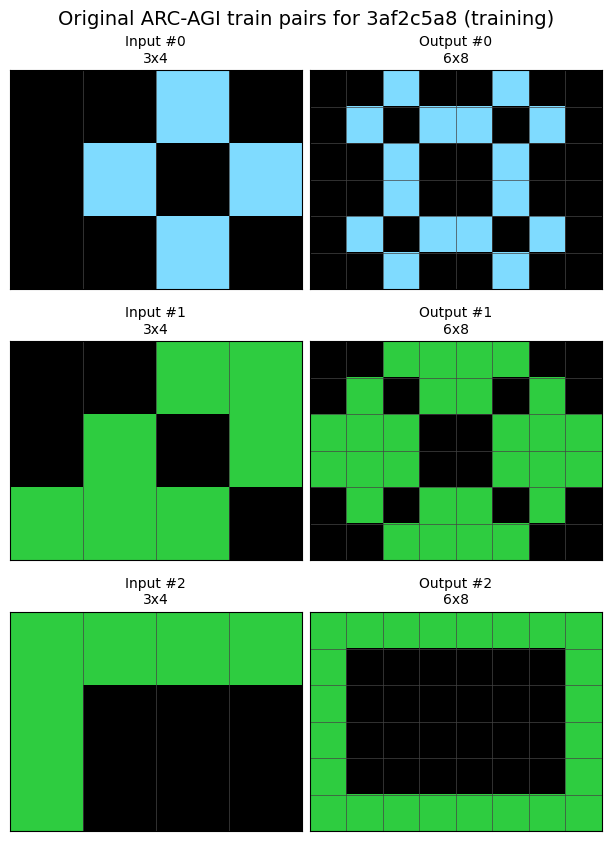

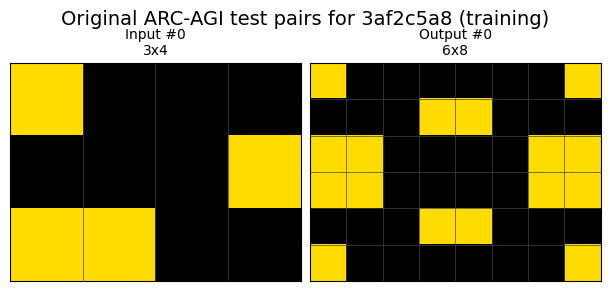

In [4]:
plot_example_pairs(
    original_train,
    title=f"Original ARC-AGI train pairs for {TASK_ID} ({subset_name})",
)

plot_example_pairs(
    original_test,
    title=f"Original ARC-AGI test pairs for {TASK_ID} ({subset_name})",
)


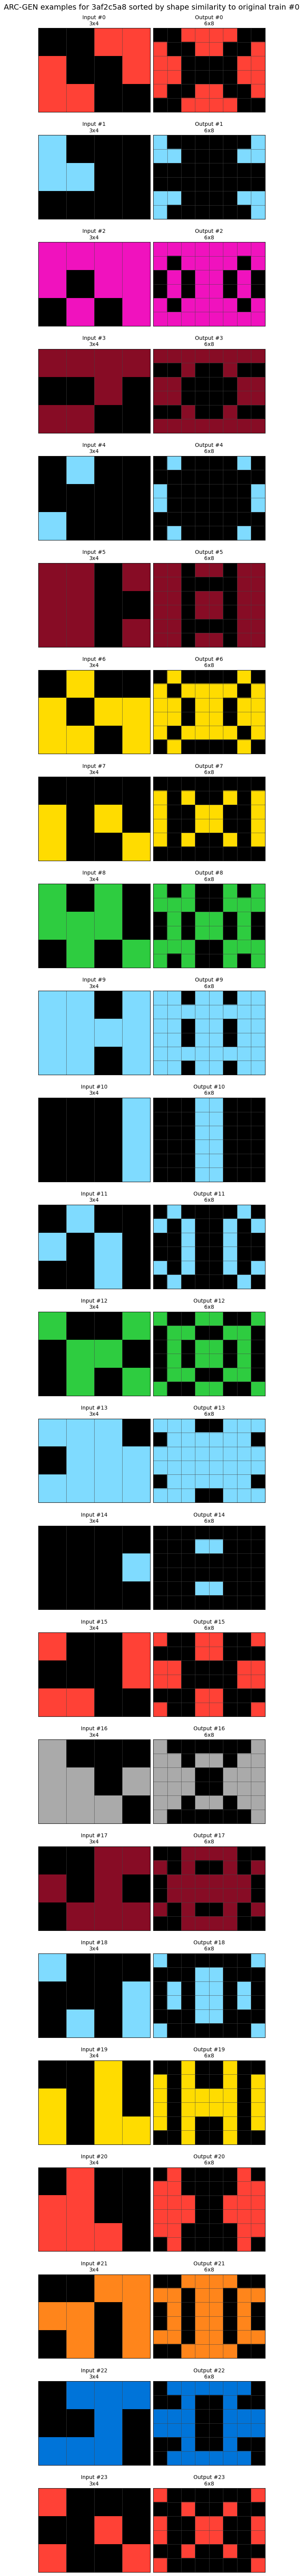

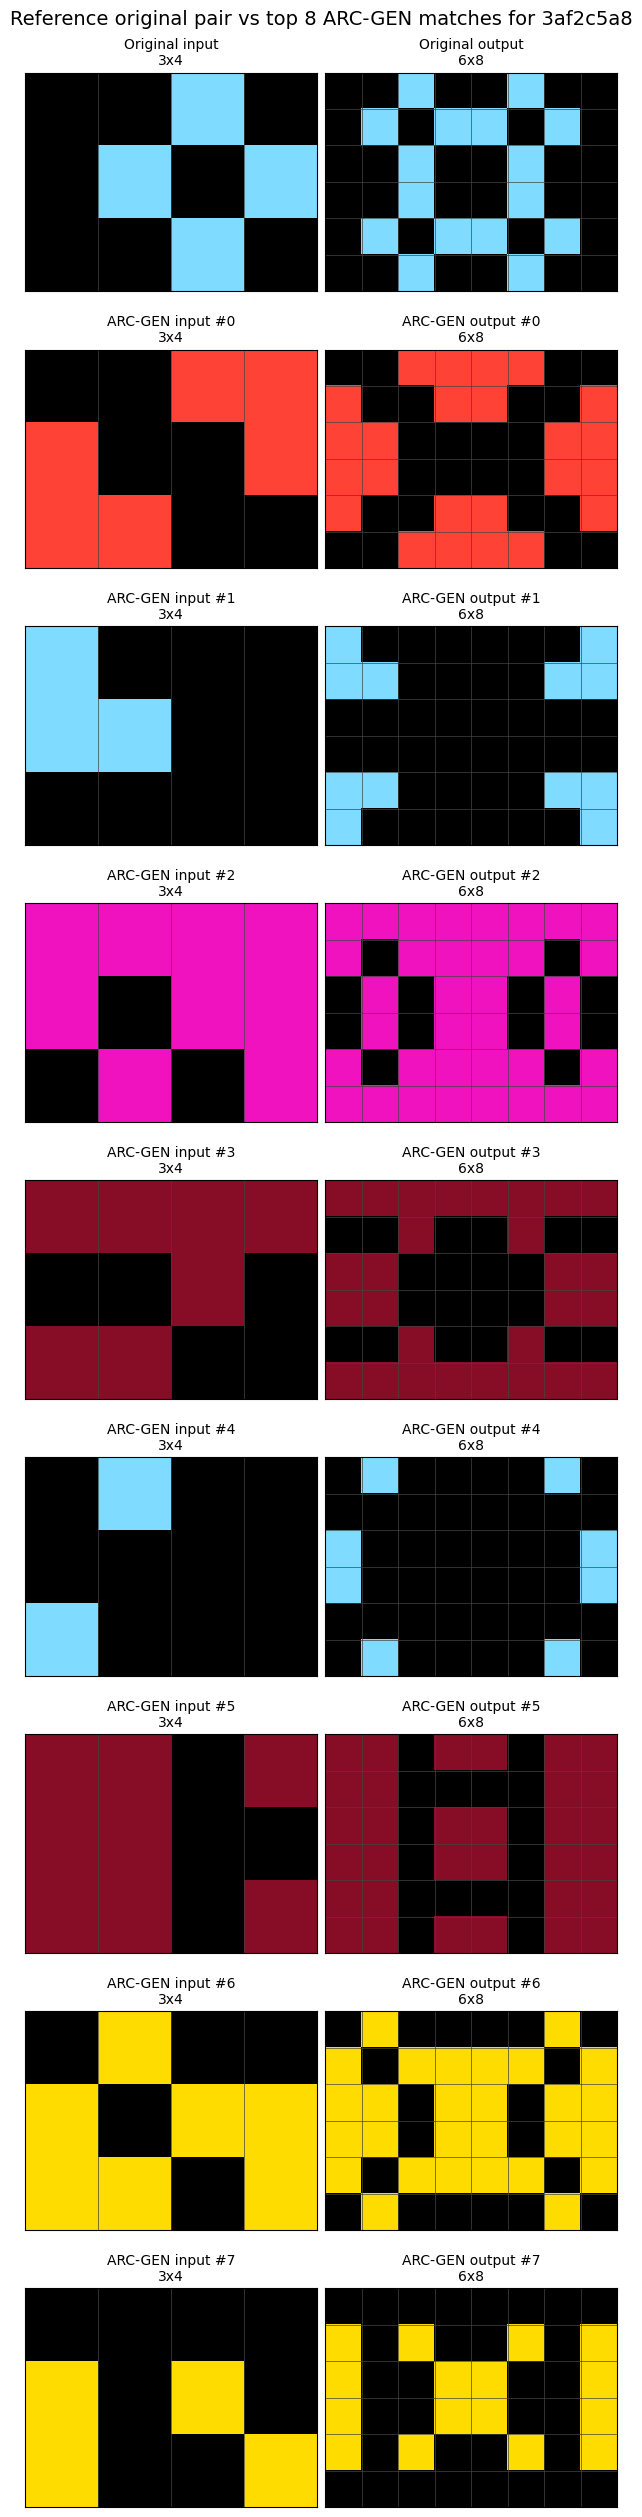

In [5]:
plot_example_pairs(
    sorted_arc_gen_examples,
    title=(
        f"ARC-GEN examples for {TASK_ID} sorted by shape similarity to original train #{reference_index}"
    ),
    max_examples=MAX_GENERATED_TO_SHOW,
)

if original_train:
    plot_reference_vs_generated(
        original_train[reference_index],
        sorted_arc_gen_examples,
        task_id=TASK_ID,
        top_k=TOP_MATCHES_TO_SHOW,
    )
